# 0 - Get corner points and px-cm (template)

Use this notebook to extract corner points and pixel/cm factors from CVAT annotations. Fill in paths and visualize results.


In [5]:
import os
WORKING_DIRECTORY = "/home/beesbook/jacob/bb_local_sync/MAIN/"
os.chdir(WORKING_DIRECTORY)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import bb_metrics
from bb_metrics.config import berlin2025 as cfg  # replace with your config
from bb_metrics import calibration as cal

# set active config for downstream functions
bb_metrics.set_config(cfg)

from bb_metrics import datafunctions as dfunc


In [7]:
# Paths from config (update in config file as needed)
images_root = cfg.comb_images_root
print(images_root)
xml_dir = cfg.calib_xml_dir
xmlfiles = sorted(xml_dir.glob('*.xml'))

xml_dfs = [cal.parse_annotation_xml(f) for f in xmlfiles]
cam_ts = cal.build_cam_timestamps(images_root)

corner_df = cal.corner_points_from_annotations(xml_dfs, xmlfiles, cam_ts)
df_px_per_cm = cal.pixels_per_cm_from_boxes(xml_dfs, xmlfiles)

display(corner_df.head())
display(df_px_per_cm.head())

outdir = Path('saved_output')
outdir.mkdir(exist_ok=True)
corner_df.to_csv(outdir / 'df_cornerpoints.csv', index=False)
df_px_per_cm.to_csv(outdir / 'df_px_per_cm.csv', index=False)


/mnt/trove/beesbook2025/comb_background


,hive,cam,timestamp,corner_x,corner_y,midday_utc
0,A,0,2025-06-17 07:29:25+00:00,242.08,73.88,2025-06-17 12:00:00+00:00
1,A,0,2025-06-18 17:29:38+00:00,242.08,73.88,2025-06-18 12:00:00+00:00
2,A,0,2025-06-19 18:59:23+00:00,242.08,73.88,2025-06-19 12:00:00+00:00
3,A,0,2025-06-20 20:00:01+00:00,242.08,73.88,2025-06-20 12:00:00+00:00
4,A,0,2025-06-23 02:58:49+00:00,400.20,79.20,2025-06-23 12:00:00+00:00


,hive,cam,pixels_per_cm
0,A,0,111.204000
1,A,1,110.640000
2,B,2,115.160000
3,B,3,110.458857
4,C,4,112.263429


## Visualize corner points

Set your manual offsets (e.g., `offset_div_cm`, `frame_width_cm`) and overlay on sample images to verify.


In [8]:
corner_df

,hive,cam,timestamp,corner_x,corner_y,midday_utc
0,A,0,2025-06-17 07:29:25+00:00,242.08,73.88,2025-06-17 12:00:00+00:00
1,A,0,2025-06-18 17:29:38+00:00,242.08,73.88,2025-06-18 12:00:00+00:00
2,A,0,2025-06-19 18:59:23+00:00,242.08,73.88,2025-06-19 12:00:00+00:00
3,A,0,2025-06-20 20:00:01+00:00,242.08,73.88,2025-06-20 12:00:00+00:00
4,A,0,2025-06-23 02:58:49+00:00,400.20,79.20,2025-06-23 12:00:00+00:00
...,...,...,...,...,...,...
415,D,7,2025-08-12 00:31:42+00:00,149.20,282.76,2025-08-12 12:00:00+00:00
416,D,7,2025-08-13 00:31:40+00:00,149.20,282.76,2025-08-13 12:00:00+00:00
417,D,7,2025-08-14 00:31:45+00:00,149.20,282.76,2025-08-14 12:00:00+00:00
418,D,7,2025-08-16 02:48:39+00:00,149.20,282.76,2025-08-16 12:00:00+00:00


In [15]:
image_filenames

['/mnt/trove/beesbook2025/comb_background/cam-1/background_cam-1_20250715T234532.291303.864Z.png',
 '/mnt/trove/beesbook2025/comb_background/cam-2/background_cam-2_20250717T213953.248160.75Z.png',
 '/mnt/trove/beesbook2025/comb_background/cam-6/background_cam-6_20250810T005407.501068.11Z.png',
 '/mnt/trove/beesbook2025/comb_background/cam-5/background_cam-5_20250628T232722.256038.952Z.png',
 '/mnt/trove/beesbook2025/comb_background/cam-5/background_cam-5_20250616T232005.798532.246Z.png',
 '/mnt/trove/beesbook2025/comb_background/cam-5/background_cam-5_20250816T095718.675755.156Z.png']

In [ ]:
# Example visualization: overlay divisions on random images
import random
from glob import glob
from bb_binary.parsing import parse_image_fname

offset_div_cm = getattr(cfg, 'offset_div_cm', 0.0)
frame_width_cm = getattr(cfg, 'frame_width_cm', 0.0)
YPIXELS = getattr(cfg, 'ypixels', None)
XPIXELS = getattr(cfg, 'xpixels', None)

print('offset_div_cm=', offset_div_cm, 'frame_width_cm=', frame_width_cm)
assert YPIXELS is not None and XPIXELS is not None, "Set ypixels/xpixels in config"

# sample images
allimages = glob(str(images_root) + '/**/*.png', recursive=True)
image_filenames = random.choices(allimages, k=min(6, len(allimages)))
image_data = [plt.imread(i) for i in image_filenames]
image_camdt = [parse_image_fname(Path(f).name.split('background_',1)[-1]) for f in image_filenames]

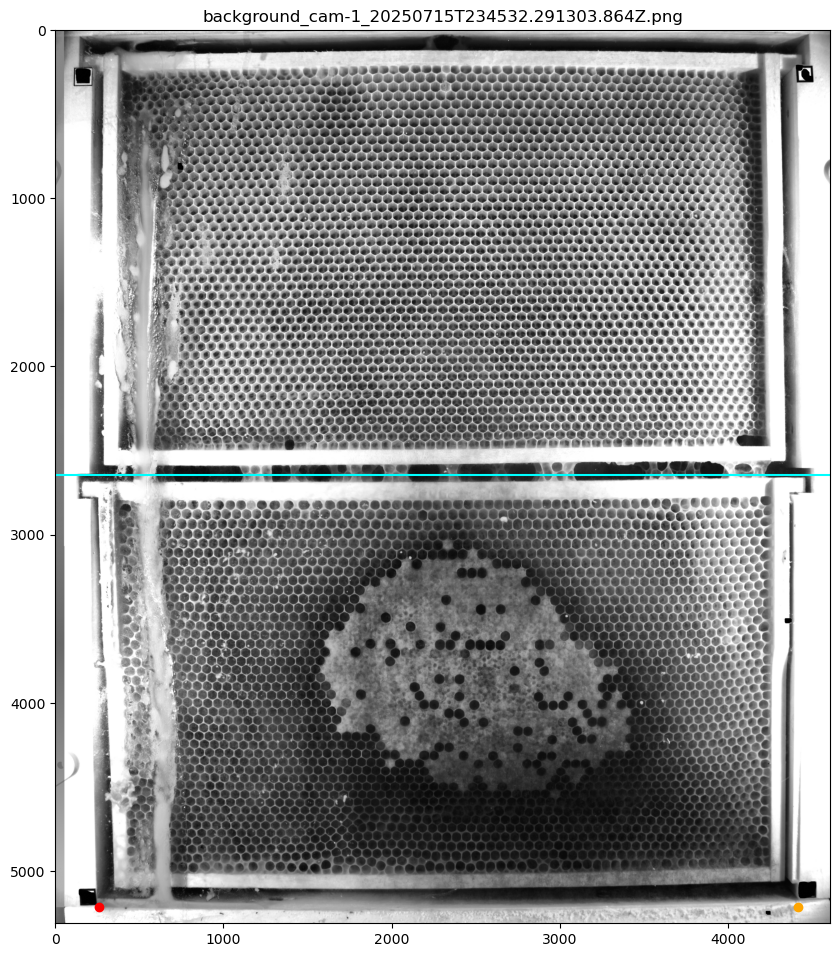

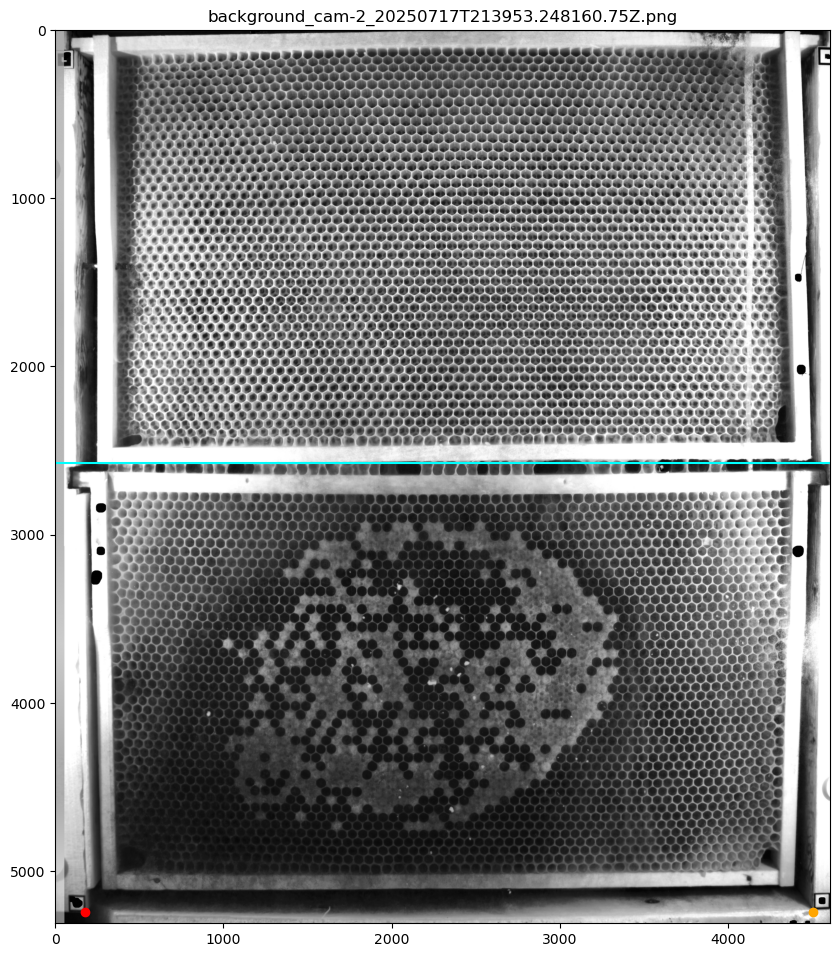

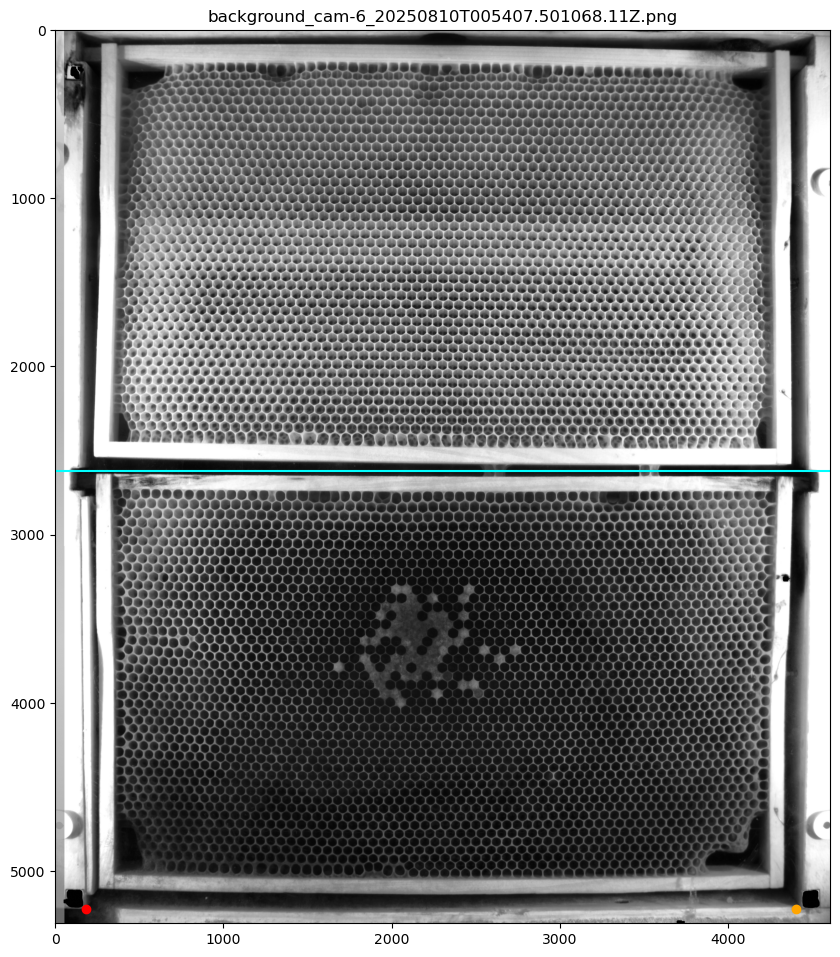

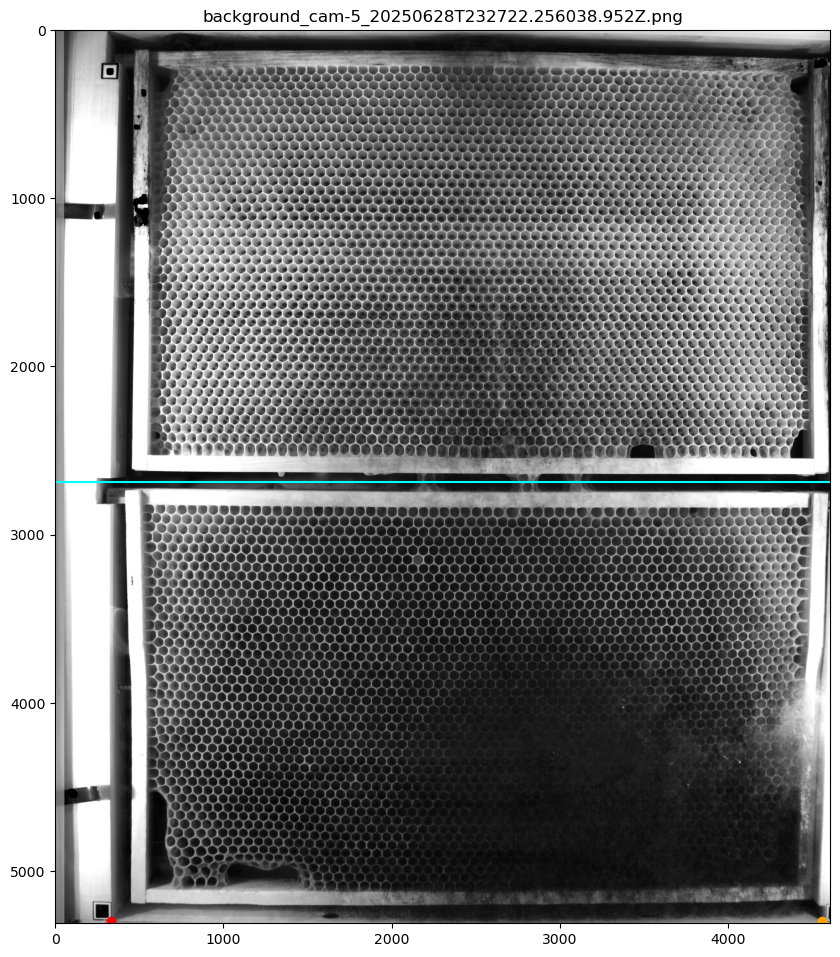

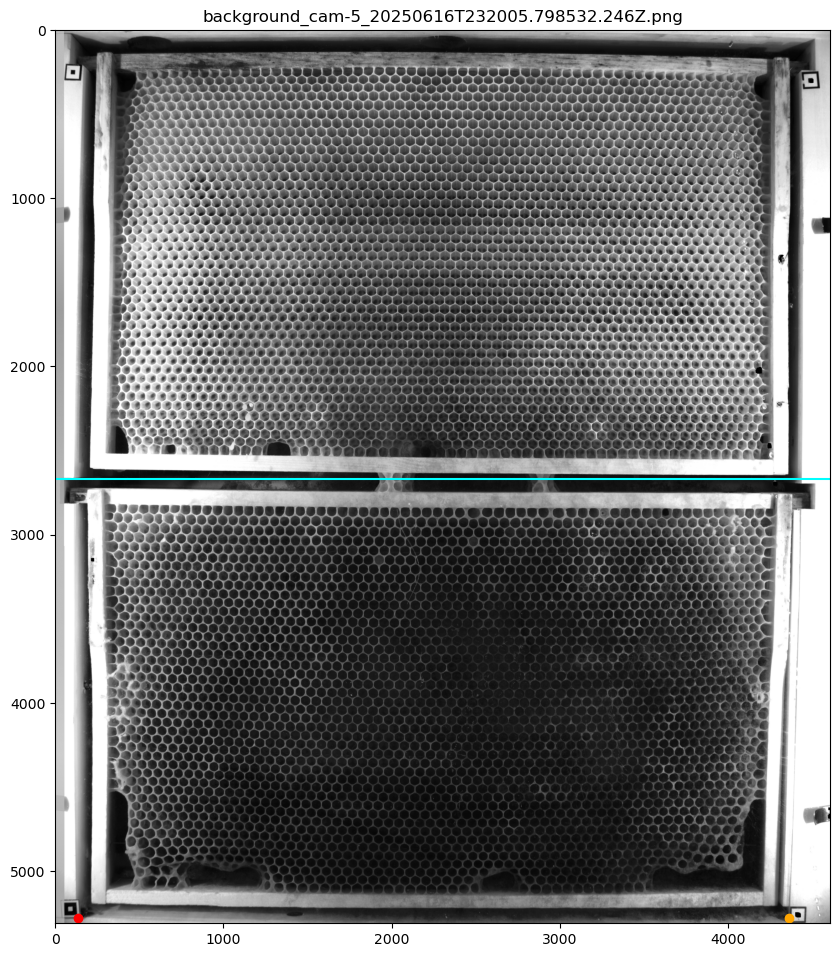

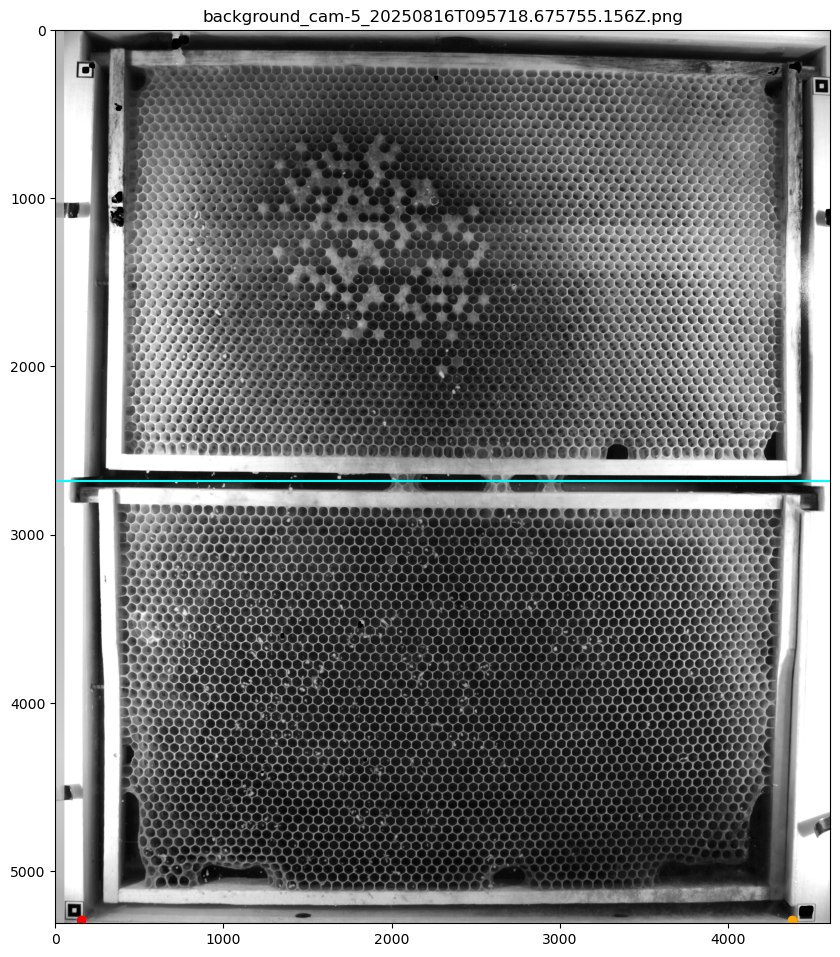

In [18]:


for img, (cam, dt), fname in zip(image_data, image_camdt, image_filenames):
    f, ax = plt.subplots(1, 1, figsize=(10, 15))
    ax.imshow(np.rot90(img, 3), cmap='gray')

    corner_x, corner_y, _ = dfunc.get_corner_point_for_date(cam, dt, corner_df)

    px_per_cm = df_px_per_cm.loc[df_px_per_cm['cam'] == cam, 'pixels_per_cm']
    if len(px_per_cm) == 0:
        continue
    px_per_cm = px_per_cm.values[0]

    ax.scatter(corner_x, YPIXELS - corner_y, c='red')
    ax.scatter(corner_x + frame_width_cm * px_per_cm, YPIXELS - corner_y, c='orange')
    ax.axhline(YPIXELS - (corner_y + offset_div_cm * px_per_cm), color='cyan')
    ax.set_title(Path(fname).name)
    plt.show()
